In [13]:
from datasets import load_dataset
import requests
import os
import json
import time
import numpy as np
import math
from tqdm import tqdm
from rank_bm25 import BM25Okapi
import dotenv
dotenv.load_dotenv()
import asyncio
import aiohttp
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from tqdm.asyncio import tqdm_asyncio
import nest_asyncio
nest_asyncio.apply()
np.random.seed(42)
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
ds = load_dataset("gsm8k", "main")["train"]
len(ds)

7473

In [3]:
ds = ds.add_column("id", list(range(len(ds))))
ds[0]

{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?',
 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72',
 'id': 0}

In [4]:
def get_embedding(text, model):
    url = "https://openrouter.ai/api/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {os.getenv("OPENROUTER_API_KEY")}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": model,
        "input": text,
        "encoding_format": "float"
    }

    r = requests.post(url, headers=headers, json=payload)
    data = r.json()
    return data["data"][0]["embedding"]

def get_embedding_batch(text_list, model):
    url = "https://openrouter.ai/api/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {os.getenv("OPENROUTER_API_KEY")}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": model,
        "input": text_list,
        "encoding_format": "float"
    }

    r = requests.post(url, headers=headers, json=payload)
    data = r.json()
    return [item["embedding"] for item in data["data"]]

# Test embeddings are correct

In [ ]:
emb = get_embedding("test sentence", "qwen/qwen3-embedding-8b")
len(emb)

v1 = get_embedding("What is your name?", "qwen/qwen3-embedding-8b")
v2 = get_embedding("How do I call you?", "qwen/qwen3-embedding-8b")
v3 = get_embedding("The sky is blue.", "qwen/qwen3-embedding-8b")

# Compute cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(cosine_similarity(v1, v2))  # Should be high
print(cosine_similarity(v1, v3))  # Should be lower

0.7017863310847171
0.5073353475470974


# This costs <$0.01
# Embed all GSM8K questions, save the embeddings

In [17]:
batch_size = 100
ds_with_emb = []

for start in tqdm(range(0, len(ds), batch_size), desc="Embedding batches"):
    end = start + batch_size
    batch = ds[start:end]
    texts = [q.strip() for q in batch["question"]]

    embeddings = get_embedding_batch(texts, "qwen/qwen3-embedding-8b")

    batch_size_actual = len(batch["question"])
    for i in range(batch_size_actual):
        new_row = {key: batch[key][i] for key in batch.keys()}
        new_row["qwen3_embed_question"] = embeddings[i]
        ds_with_emb.append(new_row)

    time.sleep(0.5)
    
with open("gsm8k_train_qwen3_question_emb.jsonl", "w") as f:
    for row in ds_with_emb:
        f.write(json.dumps(row) + "\n")

Embedding batches: 100%|██████████| 75/75 [05:40<00:00,  4.54s/it]


# Create the dense sim(i,j), normalized to span from 0 to 1

In [9]:
# JSONL files contain one JSON object per line, so read line by line
with open("data/embeddings/gsm8k_train_qwen3_question_emb.jsonl", "r") as f:
    ds_with_emb = [json.loads(line) for line in f]
emb_list = [row["qwen3_embed_question"] for row in ds_with_emb]
E = np.array(emb_list, dtype=np.float32)   # shape (7473, dim)

norm = np.linalg.norm(E, axis=1, keepdims=True)
norm = np.maximum(norm, 1e-8)  # avoid divide by zero

E_norm = E / norm

cos_matrix = E_norm @ E_norm.T

sim_dense = (cos_matrix + 1.0) / 2.0 # do the normalization conversion
sim_dense.shape

if not os.path.exists("data/similarities/gsm8k_train_qwen3_question_emb_similarity.npy"):
    np.save("data/similarities/gsm8k_train_qwen3_question_emb_similarity.npy", sim_dense)
loaded_sim = np.load("data/similarities/gsm8k_train_qwen3_question_emb_similarity.npy")
loaded_sim.shape

(7473, 7473)

# Test dense similarity nearest negihbors

In [10]:
i = 12  # choose any query index
questions = [row["question"].strip() for row in ds_with_emb]
top_neighbors = np.argsort(-sim_dense[i])[:5]

print("Query index:", i)
print("Query text:\n", questions[i], "\n")

print("\nNearest neighbors (dense similarity):")
for j in top_neighbors:
    print("Index:", j)
    print("Score:", sim_dense[i, j])
    print("Text:", questions[j])
    print()

Query index: 12
Query text:
 Randy has 60 mango trees on his farm. He also has 5 less than half as many coconut trees as mango trees. How many trees does Randy have in all on his farm? 


Nearest neighbors (dense similarity):
Index: 12
Score: 1.0
Text: Randy has 60 mango trees on his farm. He also has 5 less than half as many coconut trees as mango trees. How many trees does Randy have in all on his farm?

Index: 878
Score: 0.84361726
Text: Santino has 2 papaya trees and 3 mango trees. If each papaya tree produces 10 papayas and each mango tree produces 20 mangos, how many fruits does Santino have in total?

Index: 155
Score: 0.8385507
Text: Colby harvested his mango trees, the total mangoes he harvested is 60 kilograms. He sold 20 kilograms to the market and sold the remaining half to his community. If each kilogram contains 8 mangoes, how many mangoes does he still have?

Index: 5590
Score: 0.8366155
Text: A desert has 3/5 fewer palm trees than a nearby forest, which has 5000 palm tr

# Create the lexical sim(i,j) via min-max normalized TFIDF score

In [20]:
questions = [row["question"].strip() for row in ds_with_emb]

# Compute TF-IDF vectors for all questions
print("Computing TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer(lowercase=True, token_pattern=r'\b\w+\b')
tfidf_matrix = tfidf_vectorizer.fit_transform(questions)

N = len(questions)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Compute cosine similarity between all pairs
print("Computing cosine similarity matrix...")
tfidf_sim = cosine_similarity(tfidf_matrix).astype(np.float32)

if not os.path.exists("data/similarities/gsm8k_train_qwen3_question_tfidf_similarity.npy"):
    np.save("data/similarities/gsm8k_train_qwen3_question_tfidf_similarity.npy", tfidf_sim)

# checks
print("Symmetric? ", np.allclose(tfidf_sim, tfidf_sim.T))
print("Range: ", tfidf_sim.min(), tfidf_sim.max())
print("Example sim[0,1] and sim[1,0]: ", tfidf_sim[0,1], tfidf_sim[1,0])

Computing TF-IDF vectors...
TF-IDF matrix shape: (7473, 11954)
Computing cosine similarity matrix...
Symmetric?  True
Range:  0.0 1.0
Example sim[0,1] and sim[1,0]:  0.030457646 0.030457646


# Test lexical similarity nearest neighbors

In [21]:
i = 12  # same query index as dense case

top_neighbors = np.argsort(-tfidf_sim[i])[:5]

print("Query index:", i)
print("Query text:\n", questions[i], "\n")

print("\nNearest neighbors (TFIDF lexical similarity):")
for j in top_neighbors:
    print("Index:", j)
    print("Score:", tfidf_sim[i, j])
    print("Text:", questions[j])
    print()

Query index: 12
Query text:
 Randy has 60 mango trees on his farm. He also has 5 less than half as many coconut trees as mango trees. How many trees does Randy have in all on his farm? 


Nearest neighbors (TFIDF lexical similarity):
Index: 12
Score: 1.0
Text: Randy has 60 mango trees on his farm. He also has 5 less than half as many coconut trees as mango trees. How many trees does Randy have in all on his farm?

Index: 2995
Score: 0.502409
Text: Amiyah is cutting some trees to build a cow shade. For every tree she cuts, she plants 5 new trees. If there were 400 trees on her farm and she cut 20% of them, calculate the total number of trees on the farm.

Index: 1815
Score: 0.47914317
Text: Jim has 2 rows of 4 trees to start.  When he turns 10 he decides to plant a new row of trees every year on his birthday.  On his 15th birthday after he doubles the number of trees he has.  How many trees does he have?

Index: 5908
Score: 0.45448807
Text: Jack has a grove with 4 trees by 5 trees.  It 

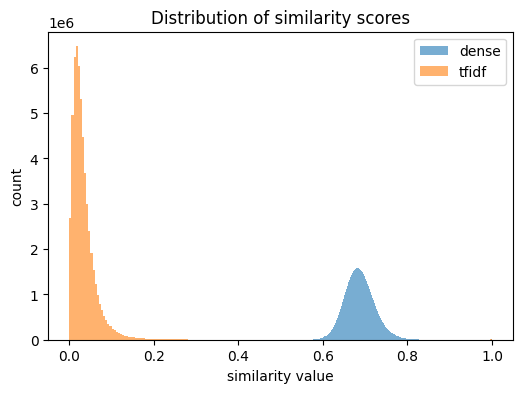

Dense mean: 0.6865399
Lexical mean: 0.034072526
Dense std: 0.035208
Lexical std: 0.03306007


In [45]:
plt.figure(figsize=(6,4))
plt.hist(sim_dense.flatten(), bins=200, alpha=0.6, label='dense')
plt.hist(tfidf_sim.flatten(), bins=200, alpha=0.6, label='tfidf')
plt.xlabel("similarity value")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of similarity scores")
plt.show()
print("Dense mean:", sim_dense.mean())
print("Lexical mean:", tfidf_sim.mean())
print("Dense std:", sim_dense.std())
print("Lexical std:", tfidf_sim.std())

## Attempt to normalize each row

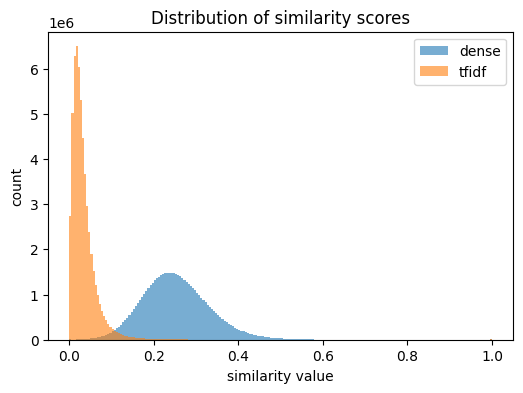

Norm Dense mean: 0.2525559
Norm Lexical mean: 0.033926405
Norm Dense std: 0.07948182
Norm Lexical std: 0.033038728


In [46]:
def row_minmax_normalize(M):
    mn = M.min(axis=1, keepdims=True)
    mx = M.max(axis=1, keepdims=True)
    return (M - mn) / (mx - mn + 1e-8)
    
dense_norm = row_minmax_normalize(sim_dense)
tfidf_norm = row_minmax_normalize(tfidf_sim)

plt.figure(figsize=(6,4))
plt.hist(dense_norm.flatten(), bins=200, alpha=0.6, label='dense')
plt.hist(tfidf_norm.flatten(), bins=200, alpha=0.6, label='tfidf')
plt.xlabel("similarity value")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of similarity scores")
plt.show()
print("Norm Dense mean:", dense_norm.mean())
print("Norm Lexical mean:", tfidf_norm.mean())
print("Norm Dense std:", dense_norm.std())
print("Norm Lexical std:", tfidf_norm.std())

## Try smooth out tfidf by square rooting all values? 

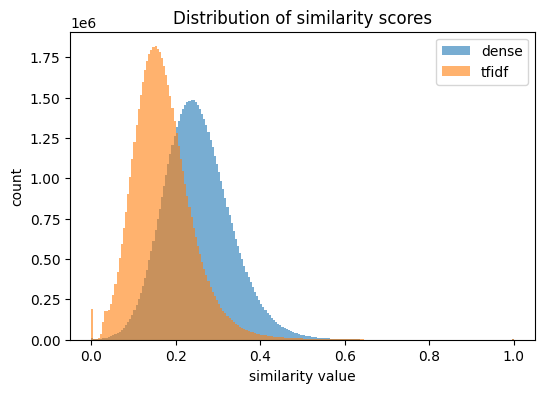

Norm Dense mean: 0.2525559
Norm Lexical mean: 0.16975859
Norm Dense std: 0.07948182
Norm Lexical std: 0.071473256


In [47]:
tfidf_norm_sqrt = np.sqrt(tfidf_norm)

plt.figure(figsize=(6,4))
plt.hist(dense_norm.flatten(), bins=200, alpha=0.6, label='dense')
plt.hist(tfidf_norm_sqrt.flatten(), bins=200, alpha=0.6, label='tfidf')
plt.xlabel("similarity value")
plt.ylabel("count")
plt.legend()
plt.title("Distribution of similarity scores")
plt.show()
print("Norm Dense mean:", dense_norm.mean())
print("Norm Lexical mean:", tfidf_norm_sqrt.mean())
print("Norm Dense std:", dense_norm.std())
print("Norm Lexical std:", tfidf_norm_sqrt.std())

# The greedy subset selection algorithm

In [18]:
def greedy_subset_selection(M, k, score_fn, z_conf, epsilon, verbose=True): 
    """
    Greedy subset selection for the facility-location objective
    with a confidence-based early stop.

    Parameters
    ----------
    M : np.ndarray
        Similarity matrix of shape (N, N), values in [0,1].
        Can be dense-only, lexical-only, or a mixed matrix.
    k : int
        Maximum subset size.
    score_fn : callable
        Function score_fn(i) → 0 or 1 for accuracy on item i.
    z_conf : float
        z-score for the desired confidence level (e.g., 1.64 for 90%).
    epsilon : float
        Allowed relative error (e.g., 0.05).
    verbose : bool
        Print progress if True.

    Returns
    -------
    S : list[int]
        Selected subset of indices.
    """
    
    N = M.shape[0]
    S = [] # final subset
    remaining = set(range(N)) # candidates not yet selected
    current_max = np.zeros(N) # the F(S) value of the current subset. Summing this up gives F(S)
    scores = [] # list of 0/1 scores
    
    while len(S) < k: 
        best_gain = -1.0
        best_i = None
        
        for i in remaining: 
            row_i = M[i] # sim to each j from i 
            gain_vector = np.maximum(current_max, row_i) - current_max # marginal gain vector
            delta = gain_vector.sum() # marginal gain if we add i to S
            if delta > best_gain: # keep track of the best i to add to S
                best_gain = delta 
                best_i = i  
                
        i_star = best_i
        S.append(i_star)
        remaining.remove(i_star)
        
        current_max = np.maximum(current_max, M[i_star]) # update current max
        
        # s_val = score_fn(i_star) # should return 0 or 1
        # scores.append(s_val)
        
        # m = len(scores)
        # mean = sum(scores) / m 
        
        # min_samples_for_ci = 10 
        # if m < min_samples_for_ci:
        #     sigma = 0.0
        #     h = float('inf')  # not used for stopping yet
        #     if verbose:
        #         print(
        #             f"Selected {i_star}, size={m}, mean={mean:.4f} "
        #             f"(not enough samples for CI; need >= {min_samples_for_ci})"
        #         )
        #     continue
        
        # if m >= 2: 
        #     sigma = math.sqrt(sum((x - mean) ** 2 for x in scores) / (m - 1))
        # else:
        #     sigma = 0
            
        # h = z_conf * sigma / math.sqrt(m)
        
        # if verbose: 
        #     print(f"Selected {i_star}, "
        #           f"size={m}, mean={mean:.4f}, h={h:.4f}, h/mean={(h/mean if mean>0 else float('inf')):.4f}")
        
        # # stop if we're confident enough
        # if mean > 0 and (h / mean) <= epsilon:
        #     if verbose:
        #         print("Stopping early due to confidence bound.")
        #     return S
    
    if verbose:
        print("Reached full budget.")
    return S

# Eval code for 1 question

In [23]:
def score_fn_gsm8k_api(i, ds, model_name="qwen/qwen-2.5-7b-instruct"):
    """
    Evaluate GSM8K item i using an OpenRouter LLM.
    Return 1 if correct, 0 otherwise.
    """

    question = ds[i]["question"]
    gold_answer_text = ds[i]["answer"]
    gold = extract_gsm8k_answer(gold_answer_text)
    if gold is None:
        return 0

    prompt = build_gsm8k_prompt(question)

    model_output = call_openrouter(model_name, prompt)
    pred = extract_predicted_number(model_output)

    if pred is None:
        return 0

    # print(f"Question: {question}")
    # print(f"Model output: {model_output}")
    # print(f"Gold: {gold}")
    # print(f"Pred: {pred}")
    # print("--------------------------------")

    return 1 if pred == gold else 0

def build_gsm8k_prompt(question):
    return (
        "Solve the following problem. You may show your reasoning.\n"
        "At the end, write the final numeric answer on a separate line in the format:\n"
        "#### <answer>\n\n"
        f"Question:\n{question}\n"
    )

def call_openrouter(model_name, prompt):
    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {os.getenv("OPENROUTER_API_KEY")}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0,  # Add this line
        "top_p": 1
    }

    response = requests.post(url, headers=headers, data=json.dumps(payload))
    data = response.json()
    
    return data["choices"][0]["message"]["content"]


def extract_gsm8k_answer(answer_text):
    # GSM8K answers end with "#### <number>"
    if "####" not in answer_text:
        return None
    tail = answer_text.split("####")[-1].strip()
    try:
        return int(tail)
    except:
        return None

def extract_predicted_number(text):
    # GSM8K answers end with "#### <number>"
    if "####" not in text:
        return None
    tail = text.split("####")[-1].strip()
    try:
        return int(tail)
    except:
        return None

In [ ]:
print(score_fn_gsm8k_api(0, ds))

# Evaluate on each subset

In [24]:
def evaluate_subset_api_and_save_summary(model_name, subset_ids, ds, dataset_name, subset_name, save_root="results"):
    """
    Evaluate a subset of GSM8K questions using an OpenRouter model.
    Save results in: results/{dataset}/{model}/{subset_name}/eval.json
    """
    
    out_dir = os.path.join(save_root, dataset_name, model_name, subset_name)
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, "eval.json")

    y_pred = []        # 0 or 1 correctness

    for qid in tqdm(subset_ids, desc="Evaluating subset"):
        score = score_fn_gsm8k_api(qid, ds, model_name) 
        y_pred.append(score)

    total = len(y_pred)
    accuracy = sum(y_pred) / total if total > 0 else 0.0

    summary = {
        "model_name": model_name,
        "dataset": dataset_name,
        "subset_name": subset_name,
        "num_evaluated": total,
        "accuracy": accuracy,
    }

    with open(save_path, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"Saved summary to {save_path}")

    return summary

### Async evaluation

In [28]:
CONCURRENCY_LIMIT = 8  # Limit concurrent OpenRouter requests

def build_gsm8k_prompt(question):
    return (
        "Solve the following problem. You may show your reasoning.\n"
        "At the end, write the final numeric answer on a separate line in the format:\n"
        "#### <answer>\n\n"
        f"Question:\n{question}\n"
    )

async def call_openrouter_async(session, model_name, prompt, semaphore):
    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {os.getenv("OPENROUTER_API_KEY")}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0,  # Add this line
        "top_p": 1
    }

    async with semaphore:
        try:
            async with session.post(url, headers=headers, json=payload) as response:
                status = response.status
                data = await response.json()

                if status != 200:
                    print(f"HTTP error: {status}")
                    print(f"Response: {data}")

                return data["choices"][0]["message"]["content"]
        except asyncio.TimeoutError:
            print("Timeout error: request took too long")
            return ""
        except Exception as e:
            print(f"Unexpected error: {e}")
            return ""

async def score_fn_gsm8k_api_async(i, ds, session, model_name, semaphore):
    question = ds[i]["question"]
    gold_answer_text = ds[i]["answer"]
    gold = extract_gsm8k_answer(gold_answer_text)

    if gold is None:
        return 0

    prompt = build_gsm8k_prompt(question)
    model_output = await call_openrouter_async(session, model_name, prompt, semaphore)
    pred = extract_predicted_number(model_output)

    if pred is None:
        return 0

    return 1 if pred == gold else 0

async def evaluate_subset_api_async(model_name, subset_ids, ds):
    semaphore = asyncio.Semaphore(CONCURRENCY_LIMIT)
    async with aiohttp.ClientSession() as session:
        tasks = [
            score_fn_gsm8k_api_async(qid, ds, session, model_name, semaphore)
            for qid in subset_ids
        ]
        results = []
        for task in tqdm_asyncio.as_completed(tasks, desc="Evaluating subset"):
            results.append(await task)
        return results

def evaluate_subset_api_and_save_summary_async(model_name, subset_ids, ds, dataset_name, subset_name, save_root="results"):
    """
    Evaluate subset using OpenRouter model asynchronously.
    Save results in: results/{dataset}/{model}/{subset_name}_eval.json
    """
    
    out_dir = os.path.join(save_root, dataset_name, model_name)
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, f"{subset_name}_eval.json")

    # Run async evaluation with concurrency control
    loop = asyncio.get_event_loop()
    if loop.is_running():
        # If in a Jupyter notebook, we need to create a task
        y_pred = loop.run_until_complete(evaluate_subset_api_async(model_name, subset_ids, ds))
    else:
        y_pred = asyncio.run(evaluate_subset_api_async(model_name, subset_ids, ds))

    total = len(y_pred)
    accuracy = sum(y_pred) / total if total > 0 else 0.0

    summary = {
        "model_name": model_name,
        "dataset": dataset_name,
        "subset_name": subset_name,
        "num_evaluated": total,
        "accuracy": accuracy,
    }

    # Load existing summaries if they exist, otherwise start a new list
    if os.path.exists(save_path):
        try:
            with open(save_path, "r") as f:
                summaries = json.load(f)
            if not isinstance(summaries, list):
                summaries = [summaries]  # Convert old format to list
        except json.JSONDecodeError:
            summaries = []
    else:
        summaries = []

    # Append new summary
    summaries.append(summary)

    # Save updated list
    with open(save_path, "w") as f:
        json.dump(summaries, f, indent=2)

    print(f"Appended new summary to {save_path}")
    return summary

In [52]:
full_ids = list(range(len(ds)))

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=full_ids,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="full_train",
)

Task was destroyed but it is pending!
task: <Task pending name='Task-53455' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-53456' coro=<Kernel.shell_main() running at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/var/folders/42/c5mdxl293jj3rldcnhqv809h0000gn/T/ipykernel_2135/2481289592.py:65: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  score_fn_gsm8k_api_async(qid, ds, session, model_name, semaphore)
Task was destroyed but it is pending!
task: <Task pending name='Task-53456' coro=<Kernel.shell_main() running at /Users/jimmynian/code/submodular_optimization/.ve

Timeout error: request took too long


Evaluating subset: 100%|██████████| 7473/7473 [49:06<00:00,  2.54it/s]  

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/full_train_eval.json


In [ ]:
random_3p5 = np.random.choice(full_ids, size=262, replace=False)
summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=random_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="random_3p5",
)

Evaluating subset: 100%|██████████| 262/262 [01:40<00:00,  2.62it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/random_3p5_eval.json


In [ ]:
random_1p0 = np.random.choice(full_ids, size=75, replace=False)
summary_full = evaluate_subset_api_and_save_summary_async(model_name="qwen/qwen-2.5-7b-instruct", subset_ids=random_1p0, ds=ds, dataset_name="gsm8k_train", 
                subset_name="random_1p0")

Evaluating subset: 100%|██████████| 75/75 [00:47<00:00,  1.58it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/random_1p0_eval.json


In [34]:
M_dense = np.load("data/similarities/gsm8k_train_qwen3_question_dense_similarity.npy")
M_lex = np.load("data/similarities/gsm8k_train_qwen3_question_tfidf_similarity.npy")
score_fn = lambda i: score_fn_gsm8k_api(i, ds)

In [55]:
dense_3p5 = greedy_subset_selection(
    M=M_dense,
    k=262,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=dense_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="dense_3p5",
)

Reached full budget.


Evaluating subset: 100%|██████████| 262/262 [01:40<00:00,  2.59it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense_3p5_eval.json


In [39]:
tfidf_3p5 = greedy_subset_selection(
    M=M_lex,
    k=262,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=tfidf_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="tfidf_3p5",
)

Reached full budget.


Evaluating subset:  77%|███████▋  | 201/262 [01:52<00:43,  1.41it/s]

Unexpected error: Response payload is not completed: <TransferEncodingError: 400, message='Not enough data to satisfy transfer length header.'>


Evaluating subset: 100%|██████████| 262/262 [02:25<00:00,  1.80it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/tfidf_3p5_eval.json


In [40]:
alpha = 0.7
M_mix = alpha * M_dense + (1 - alpha) * M_lex

mix_3p5 = greedy_subset_selection(
    M=M_mix,
    k=262,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=mix_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="dense7_tfidf3_3p5",
)

Reached full budget.


Evaluating subset: 100%|██████████| 262/262 [02:04<00:00,  2.11it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense7_tfidf3_3p5_eval.json


In [41]:
alpha = 0.5
M_mix = alpha * M_dense + (1 - alpha) * M_lex

mix_3p5 = greedy_subset_selection(
    M=M_mix,
    k=262,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=mix_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="dense5_tfidf5_3p5",
)

Reached full budget.


Evaluating subset: 100%|██████████| 262/262 [02:17<00:00,  1.91it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense5_tfidf5_3p5_eval.json


In [42]:
alpha = 0.3
M_mix = alpha * M_dense + (1 - alpha) * M_lex

mix_3p5 = greedy_subset_selection(
    M=M_mix,
    k=262,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)

summary_full = evaluate_subset_api_and_save_summary_async(
    model_name="qwen/qwen-2.5-7b-instruct",
    subset_ids=mix_3p5,
    ds=ds,
    dataset_name="gsm8k_train",
    subset_name="dense3_tfidf7_3p5",
)

Reached full budget.


Evaluating subset:  37%|███▋      | 97/262 [00:48<01:28,  1.87it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x10c3dd400> is already entered
Evaluating subset:  63%|██████▎   | 166/262 [01:28<01:05,  1.46it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x10c

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense3_tfidf7_3p5_eval.json


In [33]:
for alpha in [0.1, 0.6, 0.8, 0.9]:
    M_mix = alpha * M_dense + (1 - alpha) * M_lex
    mix_3p5 = greedy_subset_selection(
        M=M_mix,
        k=262,
        score_fn=score_fn,
        z_conf=1.64,     # 90% confidence
        epsilon=0.05,    # 5% relative error
        verbose=True,
    )
    
    # Generate subset name: dense{digit}_tfidf{last_digit}_3p5
    dense_val = int(alpha * 10)
    tfidf_val = 10 - dense_val
    subset_name = f"dense{dense_val}_tfidf{tfidf_val}_3p5"
    
    for i in range(3):
        summary_full = evaluate_subset_api_and_save_summary_async(
            model_name="qwen/qwen-2.5-7b-instruct",
            subset_ids=mix_3p5,
            ds=ds,
            dataset_name="gsm8k_train",
            subset_name=subset_name,
        )

Reached full budget.


Evaluating subset: 100%|██████████| 262/262 [01:57<00:00,  2.22it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense1_tfidf9_3p5_eval.json


Evaluating subset: 100%|██████████| 262/262 [02:11<00:00,  2.00it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense1_tfidf9_3p5_eval.json


...

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense9_tfidf0_3p5_eval.json


Evaluating subset: 100%|██████████| 262/262 [02:28<00:00,  1.76it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense9_tfidf0_3p5_eval.json


Evaluating subset: 100%|██████████| 262/262 [02:38<00:00,  1.65it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense9_tfidf0_3p5_eval.json


In [43]:
alpha = 0.7
M_mix = alpha * M_dense + (1 - alpha) * M_lex

mix_3p5 = greedy_subset_selection(
    M=M_mix,
    k=75,
    score_fn=score_fn,
    z_conf=1.64,     # 90% confidence
    epsilon=0.05,    # 5% relative error
    verbose=True,
)
for i in range(3):
    summary_full = evaluate_subset_api_and_save_summary_async(
        model_name="qwen/qwen-2.5-7b-instruct",
        subset_ids=mix_3p5,
        ds=ds,
        dataset_name="gsm8k_train",
        subset_name="dense7_tfidf3_1p0",
    )

Reached full budget.


Evaluating subset:   0%|          | 0/75 [00:00<?, ?it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-13381' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-13382' coro=<Kernel.shell_main() running at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/jimmynian/code/submodular_optimization/.venv/lib/python3.13/site-packages/aiohappyeyeballs/impl.py:15: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  async def start_connection(
Task was destroyed but it is pending!
task: <Task pending name='Task-13382' coro=<Kernel.shell_main() running at /U

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense7_tfidf3_1p0_eval.json


Evaluating subset: 100%|██████████| 75/75 [00:43<00:00,  1.71it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense7_tfidf3_1p0_eval.json


Evaluating subset: 100%|██████████| 75/75 [00:39<00:00,  1.89it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/dense7_tfidf3_1p0_eval.json


# Experiments on the normed sim matrices

In [54]:
alphas = [1]
rounds = 3
portion = "3p5"

portion_dict = {"3p5": 262, "1p0": 75}
for alpha in alphas:
    M_mix = alpha * dense_norm + (1 - alpha) * tfidf_norm_sqrt
    mix_3p5 = greedy_subset_selection(
        M=M_mix,
        k=portion_dict[portion],
        score_fn=score_fn,
        z_conf=1.64,     # 90% confidence
        epsilon=0.05,    # 5% relative error
        verbose=True,
    )
    
    # Generate subset name: dense{digit}_tfidf{last_digit}_3p5
    dense_val = int(alpha * 10)
    tfidf_val = 10 - dense_val
    subset_name = f"norm_dense{dense_val}_norm_tfidf{tfidf_val}_{portion}"
    
    for i in range(rounds):
        summary_full = evaluate_subset_api_and_save_summary_async(
            model_name="qwen/qwen-2.5-7b-instruct",
            subset_ids=mix_3p5,
            ds=ds,
            dataset_name="gsm8k_train",
            subset_name=subset_name,
        )

Reached full budget.


Evaluating subset: 100%|██████████| 262/262 [03:01<00:00,  1.44it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/norm_dense10_norm_tfidf0_3p5_eval.json


Evaluating subset: 100%|██████████| 262/262 [02:41<00:00,  1.62it/s]


Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/norm_dense10_norm_tfidf0_3p5_eval.json


Evaluating subset: 100%|██████████| 262/262 [02:53<00:00,  1.51it/s]

Appended new summary to results/gsm8k_train/qwen/qwen-2.5-7b-instruct/norm_dense10_norm_tfidf0_3p5_eval.json


# Plot 2 D visualizations of the subset among all samples

In [101]:
def plot_subset_projection(M, S):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(M)
    mask = np.zeros(len(M), dtype=bool)
    mask[S] = True
    plt.figure(figsize=(10, 10))
    plt.scatter(X_2d[~mask, 0], X_2d[~mask, 1], s=10, color="gray", alpha=0.3)
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=20, color="red", alpha=0.9)
    plt.title("2D Projection of Similarity Rows\nGray = all points, Red = selected subset")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
# def plot_coverage_heatmap(E, M, S):
#     coverage = np.max(M[S], axis=0)    # shape (N,)
#     norm = Normalize(vmin=coverage.min(), vmax=coverage.max())
#     pca = PCA(n_components=2)
#     X_2d = pca.fit_transform(E)        # E can be (7476, 4096)
#     plt.figure(figsize=(10, 10))
#     sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=coverage, cmap="gray_r", norm=norm, s=3, alpha=0.8)
#     plt.scatter(X_2d[S, 0], X_2d[S, 1], color="red", s=15, alpha=1.0)
#     plt.colorbar(sc, label="Coverage score (max similarity to S)")
#     plt.title("Coverage Heatmap in 2D\nRed = selected subset")
#     plt.xlabel("PC1")
#     plt.ylabel("PC2")
#     plt.show()


def plot_coverage_heatmap(E, M, S):
    coverage = np.max(M[S], axis=0)  # shape (N,)
    
    # Filter points with coverage >= 0.7
    mask = coverage >= 0.7
    coverage_filtered = coverage[mask]
    E_filtered = E[mask]
    
    # Create white-to-red colormap
    cmap = LinearSegmentedColormap.from_list("white_to_red", ["white", "red"])
    
    norm = Normalize(vmin=0.7, vmax=1.0)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(E_filtered)
    
    plt.figure(figsize=(10, 10))
    sc = plt.scatter(
        X_2d[:, 0], X_2d[:, 1], 
        c=coverage_filtered, cmap=cmap, norm=norm, s=5, alpha=0.9
    )
    
    # Plot selected subset with black border
    S_filtered = [i for i in S if coverage[i] >= 0.7]
    X_2d_S = pca.transform(E[S_filtered])
    plt.scatter(
        X_2d_S[:, 0], X_2d_S[:, 1], 
        facecolor="red", edgecolor="black", s=50, linewidth=1.2, alpha=1.0
    )
    
    plt.colorbar(sc, label="Coverage score (max similarity to S)")
    plt.title("Coverage Heatmap in 2D\nRed = selected subset (coverage ≥ 0.7)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [83]:
ds_with_emb = []

with open("/Users/jimmynian/code/submodular_optimization/data/embeddings/gsm8k_train_qwen3_question_emb.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)     
        ds_with_emb.append(obj)
emb_list = [row["qwen3_embed_question"] for row in ds_with_emb]
E = np.array(emb_list, dtype=np.float32)   # shape (7473, dim)

Reached full budget.


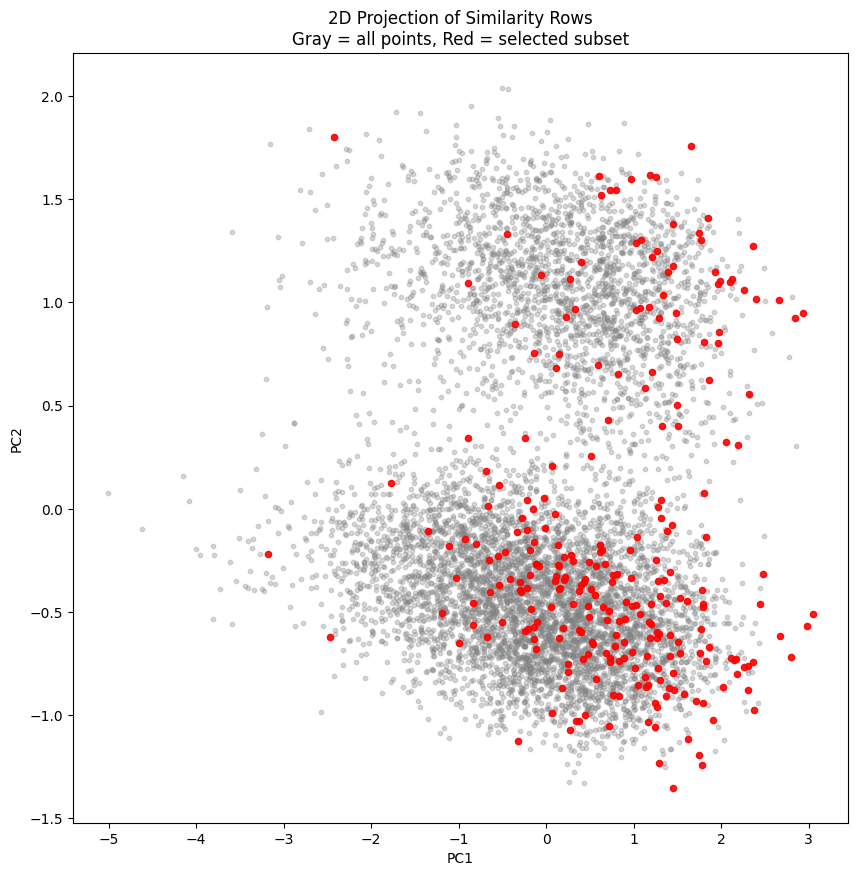

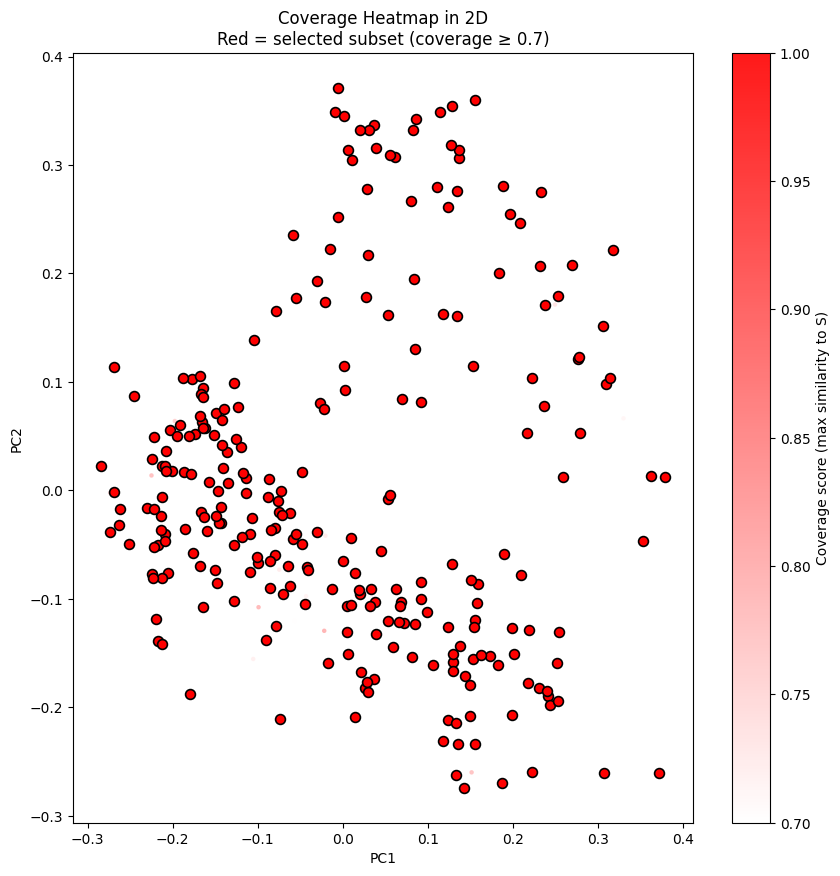

In [102]:
alpha = 0.7
M_mix = alpha * M_dense + (1 - alpha) * M_lex_symmetric
mix_3p5 = greedy_subset_selection(M=M_mix, k=262, score_fn=score_fn, z_conf=1.64, epsilon=0.05, verbose=True)
plot_subset_projection(M_mix, mix_3p5)
plot_coverage_heatmap(E, M_mix, mix_3p5)

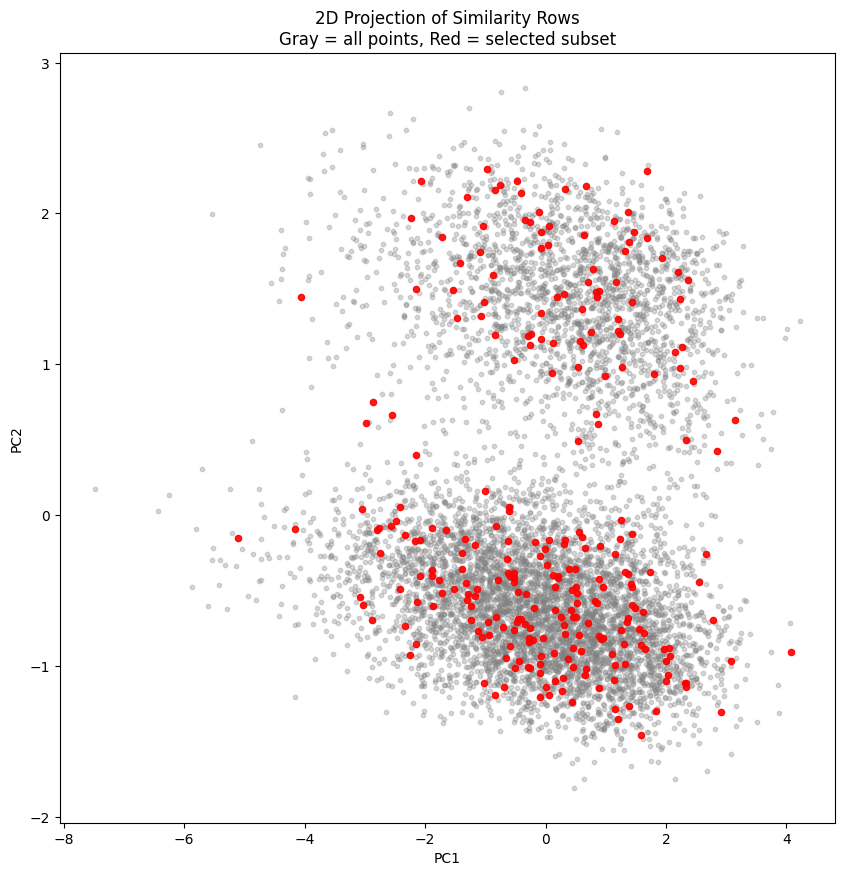

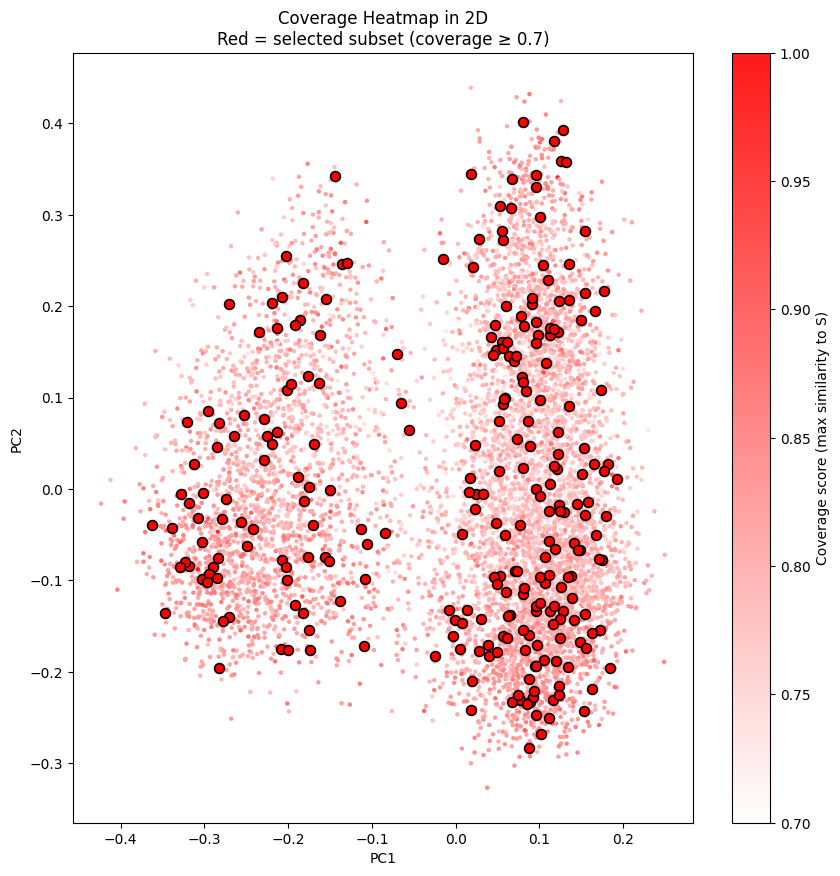

In [103]:
random_3p5 = np.random.choice(full_ids, size=262, replace=False)
plot_subset_projection(M_dense, random_3p5)
plot_coverage_heatmap(E, M_dense, random_3p5)